##### Setup

In [ ]:
%pip install numpy pandas seaborn matplotlib scikit-learn ipython

##### Change to root for accessing data directory

In [ ]:
import os
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == "notebooks" and Path.exists(current_dir.parent / Path("data")):
    os.chdir(current_dir.parent)
    print(f"Current directory: {Path.cwd()}")
elif current_dir.name == "dt133g-thesis-project":
    print(f"Current directory: {Path.cwd()}")
else:
    print("Ensure data exists before running this notebook..")
    

##### Imports and model names

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import f1_score
from IPython.display import display

pretrained_models = {
    "cb": "microsoft/codebert-base",
    "gc": "microsoft/graphcodebert-base", 
    "ux": "microsoft/unixcoder-base",
    "ct": "Salesforce/codet5p-770m",
    "ds": "deepseek-ai/deepseek-coder-1.3b-base",
}


##### Load DataFrame and set figure save path

In [4]:
# DATASET_NAME = "droidcollection"
DATASET_NAME = "codet_m4"

FIGURE_OUTDIR = Path("output/figures")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


file_paths = []
for key, full_name in pretrained_models.items():

    FULL_MODEL_NAME = full_name
    MODEL_NAME = FULL_MODEL_NAME.split("/")[-1].rsplit("-")[0]

    file_paths.append(Path(f"data/fine_tune/models/{DATASET_NAME}/{FULL_MODEL_NAME}/eval_outputs/ood_metrics_{MODEL_NAME}.csv"))

df_raw = pd.concat(pd.read_csv(file) for file in file_paths)

ALL_MODELS = df_raw["model_name"].unique()
TIER_ORDER = df_raw["tier"].unique()

print("CSV Files:")
print(",\n".join([path.as_posix() for path in file_paths]))
print("-"*66)
print("DataFrame Columns:")
print(df_raw.columns.values)
print("-"*66)
print("Model Names:")
print(ALL_MODELS)
print("-"*66)
print("Tiers:")
print(TIER_ORDER)


CSV Files:
data/fine_tune/models/codet_m4/microsoft/codebert-base/eval_outputs/ood_metrics_codebert.csv,
data/fine_tune/models/codet_m4/microsoft/graphcodebert-base/eval_outputs/ood_metrics_graphcodebert.csv,
data/fine_tune/models/codet_m4/microsoft/unixcoder-base/eval_outputs/ood_metrics_unixcoder.csv,
data/fine_tune/models/codet_m4/Salesforce/codet5p-770m/eval_outputs/ood_metrics_codet5p.csv,
data/fine_tune/models/codet_m4/deepseek-ai/deepseek-coder-1.3b-base/eval_outputs/ood_metrics_deepseek.csv
------------------------------------------------------------------
DataFrame Columns:
['model_name' 'model_type' 'tier' 'snippet_id' 'true_label' 'pred_label'
 'is_correct' 'conf_target' 'entropy' 'mutual_info']
------------------------------------------------------------------
Model Names:
['codebert' 'graphcodebert' 'unixcoder' 'codet5p' 'deepseek']
------------------------------------------------------------------
Tiers:
['test' 'tier_1' 'tier_2' 'tier_3' 'tier_4']


## General Analysis

##### Helpers

In [5]:
from pandas import DataFrame


def save_figure(fig, name, dpi=300):
    pdf_path = FIGURE_OUTDIR / f"{name}.pdf"
    fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {pdf_path}")


def build_metrics_summary(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    df_clean = df_source.copy()

    df_clean = df_clean[df_clean["true_label"] != "true_label"]
    df_clean = df_clean.dropna(subset=["true_label", "pred_label"])

    df_clean["true_label"] = df_clean["true_label"].astype(float).astype(int)
    df_clean["pred_label"] = df_clean["pred_label"].astype(float).astype(int)
    df_clean["entropy"] = pd.to_numeric(df_clean["entropy"], errors="coerce")
    df_clean["mutual_info"] = pd.to_numeric(
        df_clean["mutual_info"], errors="coerce"
    )

    metrics_rows = []

    for model in models:
        for tier in tiers:
            slice_df = df_clean[
                (df_clean["model_name"] == model) & (df_clean["tier"] == tier)
            ]

            if slice_df.empty:
                continue
            
            y_true = slice_df["true_label"].to_numpy()
            y_pred = slice_df["pred_label"].to_numpy()
            entropy = slice_df["entropy"].dropna().to_numpy()
            mutual_info = slice_df["mutual_info"].dropna().to_numpy()

            row = {
                "model_name": model,
                "tier": tier,
                "accuracy": float(np.mean(y_true == y_pred)),
                "macro_f1": float(
                    f1_score(y_true, y_pred, average="macro", zero_division=0)
                ),
                "entropy": float(np.mean(entropy)),
                "entropy_std": float(np.std(entropy, ddof=0)),
                "mutual_info": float(np.mean(mutual_info)),
                "mutual_info_std": float(np.std(mutual_info, ddof=0)),
            }
            metrics_rows.append(row)

    return pd.DataFrame(metrics_rows)

def build_delta_summary(df_source, baseline="test"):
    summary_df = df_source.copy()

    baseline = (
        summary_df[summary_df["tier"] == baseline]
        .rename(columns={
            "accuracy": "baseline_accuracy",
            "macro_f1": "baseline_macro_f1",
            "entropy": "baseline_entropy",
            "mutual_info": "baseline_mutual_info",
            "entropy_std": "baseline_entropy_std",
            "mutual_info_std": "baseline_mutual_info_std",
        })[["model_name", "baseline_accuracy", "baseline_macro_f1", "baseline_entropy", "baseline_mutual_info", "baseline_entropy_std", "baseline_mutual_info_std"]]
    )
    summary_df = summary_df.merge(baseline, on="model_name", how="left")

    summary_df["accuracy_delta"] = summary_df["accuracy"] - summary_df["baseline_accuracy"]
    summary_df["macro_f1_delta"] = summary_df["macro_f1"] - summary_df["baseline_macro_f1"]
    summary_df["entropy_delta"] = summary_df["entropy"] - summary_df["baseline_entropy"]
    summary_df["mutual_info_delta"] = summary_df["mutual_info"] - summary_df["baseline_mutual_info"]

    return summary_df


##### Plot configuration

In [6]:
METRICS_LIST = ["accuracy", "macro_f1", "entropy", "mutual_info"]

sns.set_style("whitegrid")
palette = sns.color_palette("deep", n_colors=len(ALL_MODELS))
MODEL_COLORS = {model: color for model, color in zip(ALL_MODELS, palette)}
HEATMAP_NEG = sns.color_palette("viridis", as_cmap=True)
HEATMAP_POS = sns.color_palette("viridis_r", as_cmap=True)

MODEL_LABELS = {
    "codebert": "CodeBERT",
    "graphcodebert": "GraphCodeBERT",
    "unixcoder": "UniXcoder",
    "codet5p": "CodeT5+",
    "deepseek": "DeepSeek Coder",
}

TIER_LABELS = {
    "test": "base (T0)",
    "tier_1": "surface (T1)",
    "tier_2": "natural (T2)",
    "tier_3": "adversarial (T3)",
    "tier_4": "destructive (T4)"
}

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "entropy": "Predictive Entropy",
    "mutual_info": "Mutual Information",
}

METRIC_DELTA_LABELS = {
    "accuracy": "Δ Accuracy",
    "macro_f1": "Δ Macro-F1",
    "entropy": "Δ Predictive Entropy",
    "mutual_info": "Δ Mutual Information",
}


#### Generate Tables

In [7]:
def build_comparison_tables(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    table_a_rows = []
    table_b_rows = []

    df_summary = build_metrics_summary(df_source)
    df_deltas = build_delta_summary(df_summary)

    for model in models:
        model_summary = df_summary[df_summary["model_name"] == model]
        model_deltas = df_deltas[df_deltas["model_name"] == model]

        test_df = model_summary[model_summary["tier"] == "test"]
        if test_df.empty:
            continue

        table_a_rows.append(
            {
                "Model": MODEL_LABELS[model],
                "Baseline Accuracy": test_df["accuracy"].item(),
                "Baseline Macro-F1": test_df["macro_f1"].item(),
                "Mean Entropy": test_df["entropy"].item(),
                "Std Entropy": test_df["entropy_std"].item(),
                "Mean Mutual Info": test_df["mutual_info"].item(),
                "Std Mutual Info": test_df["mutual_info_std"].item(),
            }
        )

        tier4_delta = model_deltas[model_deltas["tier"] == "tier_4"]
        if tier4_delta.empty:
            continue

        active_tiers_delta = model_deltas[model_deltas["tier"].isin(tiers)]

        table_b_rows.append(
            {
                "Model": MODEL_LABELS[model],
                "Total Acc. Loss (T4)": tier4_delta["accuracy_delta"].item(),
                "Total F1 Loss (T4)": tier4_delta["macro_f1_delta"].item(),
                "Mean Entropy": active_tiers_delta["entropy_delta"].mean(),
                "Mean Mutual Info": active_tiers_delta["mutual_info_delta"].mean(),
            }
        )

    table_a = pd.DataFrame(table_a_rows)
    table_b = pd.DataFrame(table_b_rows)

    return table_a, table_b

comparison_table_a, comparison_table_b = build_comparison_tables(df_raw)

ds_title = f"[{DATASET_NAME.upper().replace('_', '-')}]"
print(f"Table A: Absolute Baseline Performance ({ds_title})")
display(comparison_table_a.style.hide(axis="index").format({
    "Baseline Accuracy": "{:.3f}",
    "Baseline Macro-F1": "{:.3f}",
    "Mean Entropy": "{:.3f}",
    "Std Entropy": "(±{:.3f})",
    "Mean Mutual Info": "{:.3f}",
    "Std Mutual Info": "(±{:.3f})",
}))

print(f"\nTable B: Tier-by-Tier Decay Summary ({ds_title})")
display(comparison_table_b.style.hide(axis="index").format({
    "Total Acc. Loss (T4)": "{:+.3f}",
    "Total F1 Loss (T4)": "{:+.3f}",
    "Mean Entropy": "{:+.3f}",
    "Mean Mutual Info": "{:+.3f}",
}))


Table A: Absolute Baseline Performance ([CODET-M4])


Model,Baseline Accuracy,Baseline Macro-F1,Mean Entropy,Std Entropy,Mean Mutual Info,Std Mutual Info
CodeBERT,0.989,0.989,0.010,(±0.058),0.003,(±0.032)
GraphCodeBERT,0.991,0.991,0.008,(±0.055),0.003,(±0.028)
UniXcoder,0.962,0.962,0.020,(±0.094),0.009,(±0.051)
CodeT5+,0.992,0.992,0.012,(±0.071),0.001,(±0.008)
DeepSeek Coder,0.821,0.821,0.255,(±0.256),0.063,(±0.082)



Table B: Tier-by-Tier Decay Summary ([CODET-M4])


Model,Total Acc. Loss (T4),Total F1 Loss (T4),Mean Entropy,Mean Mutual Info
CodeBERT,-0.248,-0.257,+0.034,+0.019
GraphCodeBERT,-0.206,-0.207,+0.041,+0.022
UniXcoder,-0.289,-0.315,+0.023,+0.013
CodeT5+,-0.216,-0.216,+0.050,+0.006
DeepSeek Coder,-0.311,-0.352,+0.045,+0.013


##### Generate Line Plots

Saved: output\figures\codet_m4_line_accuracy.pdf


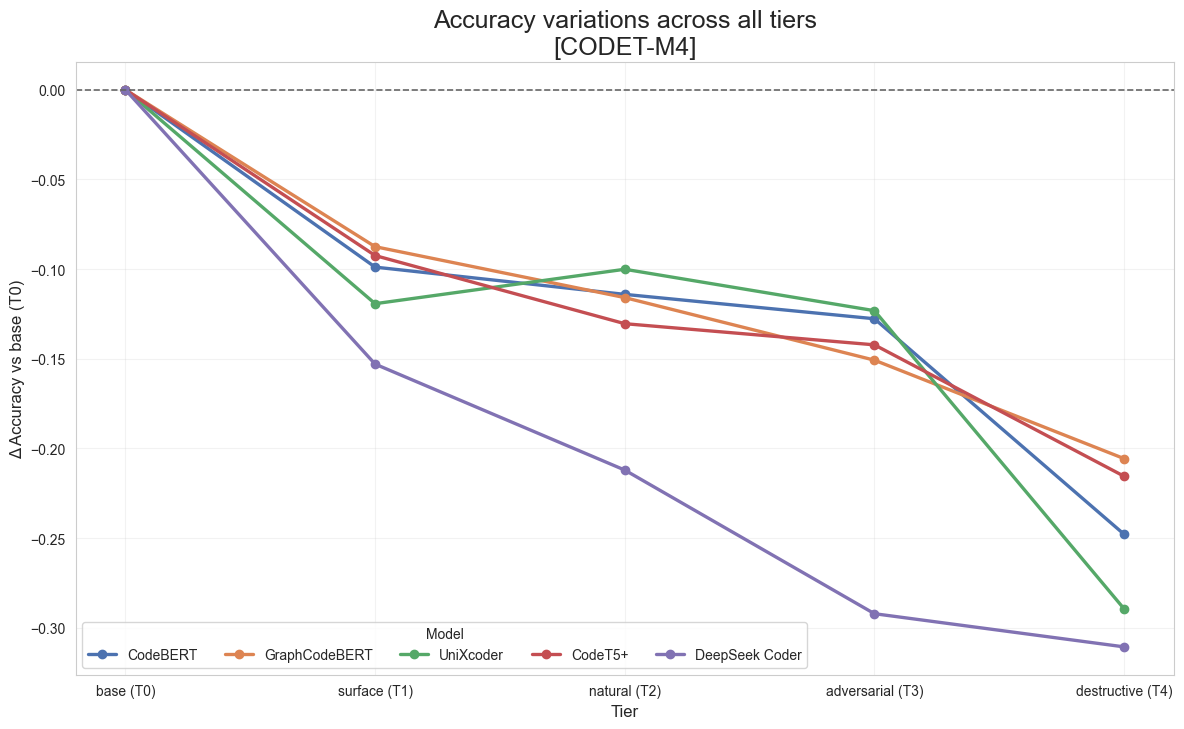

Saved: output\figures\codet_m4_line_macro_f1.pdf


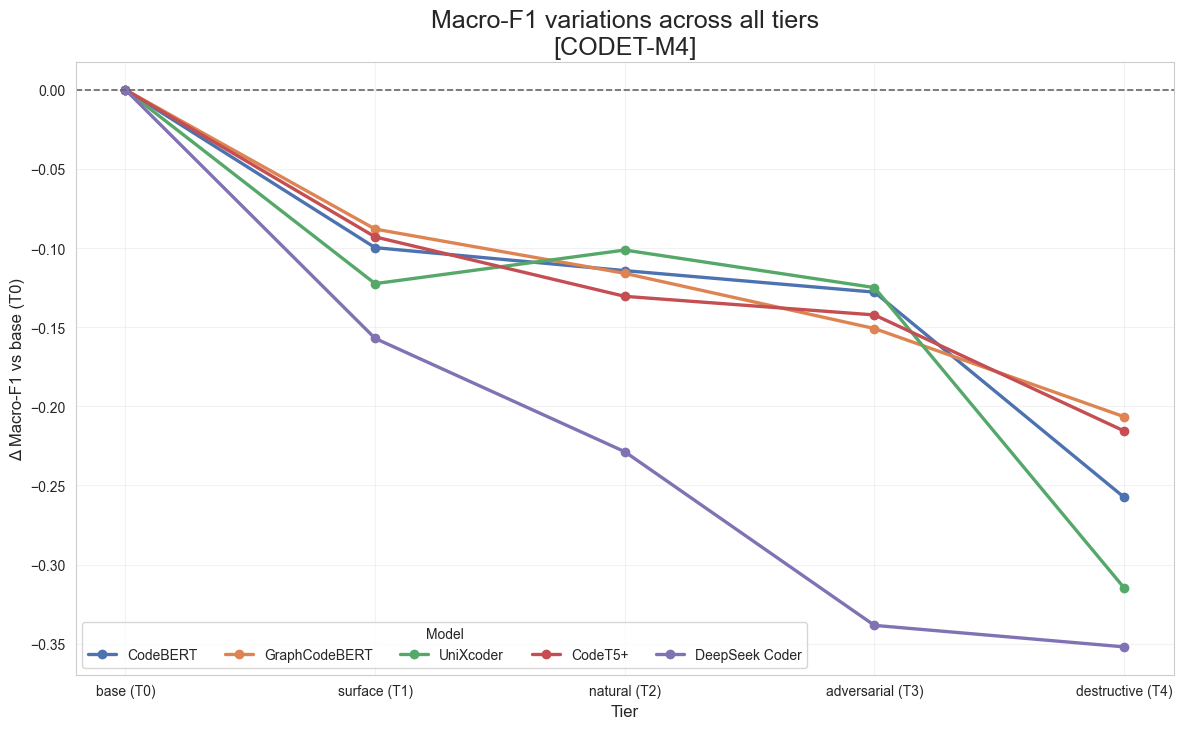

,model_name,tier,accuracy,macro_f1,entropy,entropy_std,mutual_info,mutual_info_std
0,codebert,test,0.9892,0.989200,0.010316,0.057795,0.003325,0.032253
1,codebert,tier_1,0.8903,0.889461,0.032264,0.113751,0.017008,0.078592
2,codebert,tier_2,0.8751,0.874946,0.043693,0.131140,0.022323,0.085900
3,codebert,tier_3,0.8615,0.861350,0.053532,0.145420,0.028329,0.097433
4,codebert,tier_4,0.7413,0.731748,0.081954,0.173247,0.039477,0.109799


In [8]:
def plot_line(delta_df, metrics, tiers=TIER_ORDER, models=ALL_MODELS):
    pretty_tiers = [TIER_LABELS[t] for t in tiers]

    for metric in metrics:
        if metric not in ["accuracy", "macro_f1"]:
            continue
        fig, ax = plt.subplots(figsize=(12, 7.4))

        for model in models:
            model_df = (
                delta_df[delta_df["model_name"] == model]
                .set_index("tier")
                .reindex(tiers)
            )

            deltas = model_df[f"{metric}_delta"]
            if deltas.dropna().empty:
                continue

            ax.plot(
                np.arange(len(tiers)),
                deltas.values,
                marker="o",
                linewidth=2.4,
                color=MODEL_COLORS.get(model, "#333333"),
                label=MODEL_LABELS[model],
            )

        ax.axhline(0.0, color="#666666", linestyle="--", linewidth=1.2)
        ds_name = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        metric_name = f"{METRIC_LABELS[metric]}"
        ax.set_title(
            f"{metric_name} variations across all tiers\n{ds_name}",
            fontsize=18,
        )
        ax.set_xlabel("Tier", fontsize=12)
        ax.set_ylabel(f"{METRIC_DELTA_LABELS[metric]} vs {TIER_LABELS['test']}", fontsize=12)
        ax.set_xticks(np.arange(len(tiers)))
        ax.set_xticklabels(pretty_tiers)
        ax.grid(alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles,
                labels,
                title="Model",
                ncol=min(len(labels), 5),
                frameon=True,
                fontsize=10,
            )

        fig.tight_layout()

        save_figure(fig, f"{DATASET_NAME}_line_{metric}")

        plt.show()


summary_df = build_metrics_summary(df_raw)
delta_df = build_delta_summary(summary_df)

plot_line(
    delta_df,
    METRICS_LIST,
    tiers=TIER_ORDER,
    models=ALL_MODELS,
)

summary_df.head()


##### Generate KDE plots (MI vs Entropy)

Saved: output\figures\codet_m4_mi_entropy_kde_codebert.pdf


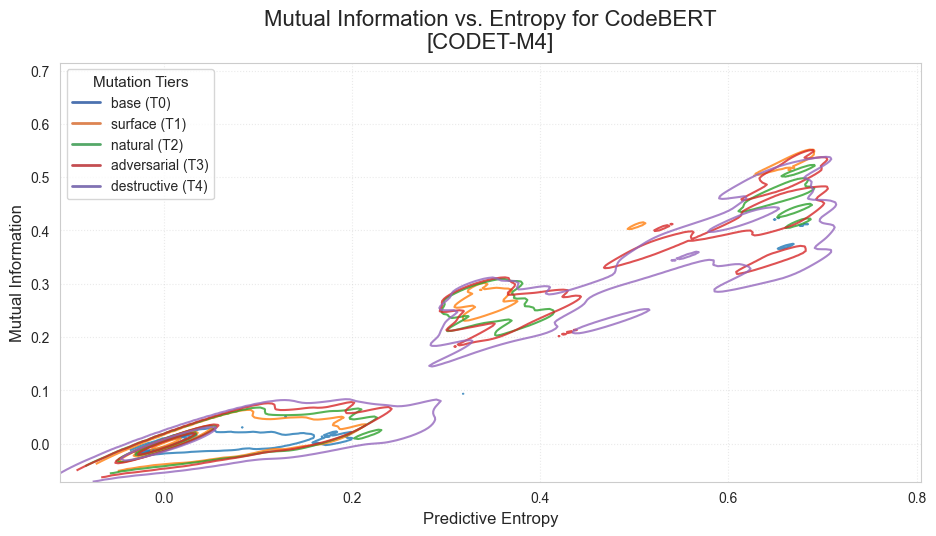

Saved: output\figures\codet_m4_mi_entropy_kde_graphcodebert.pdf


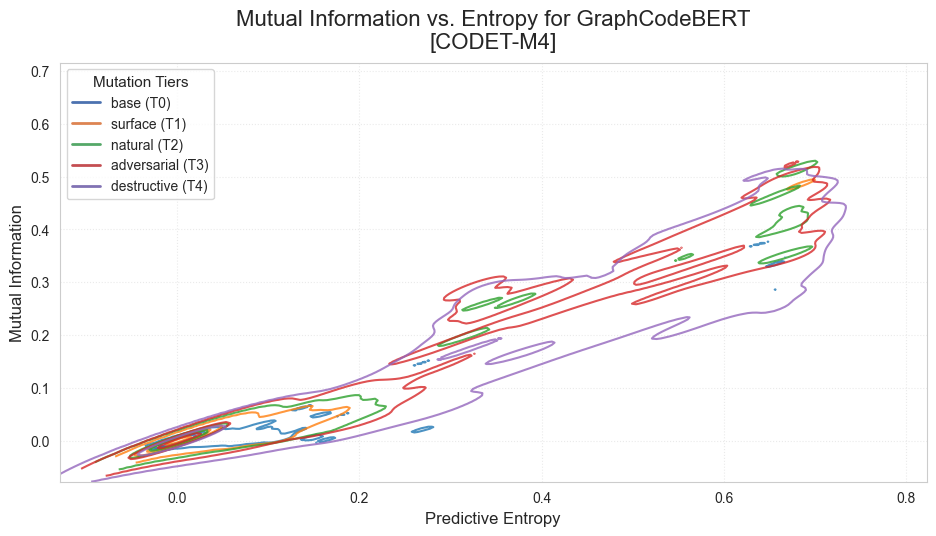

Saved: output\figures\codet_m4_mi_entropy_kde_unixcoder.pdf


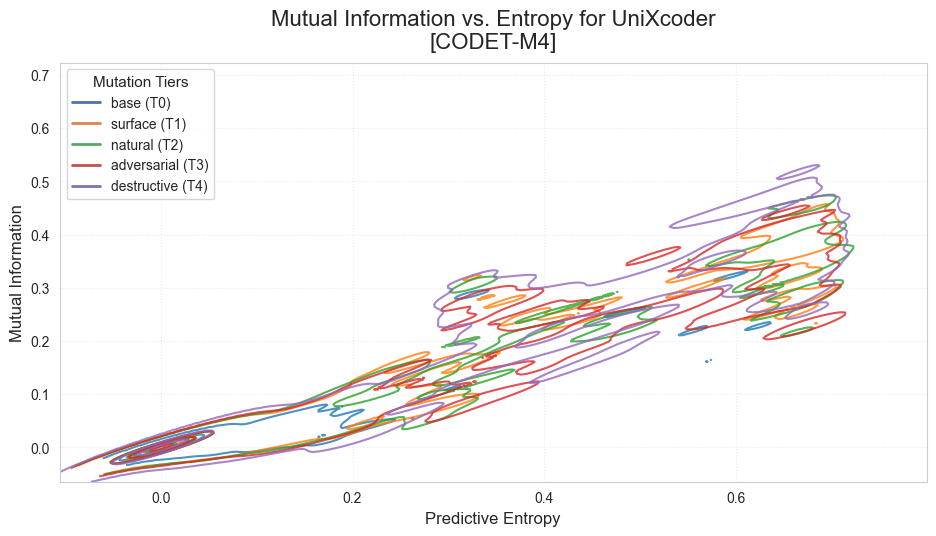

Saved: output\figures\codet_m4_mi_entropy_kde_codet5p.pdf


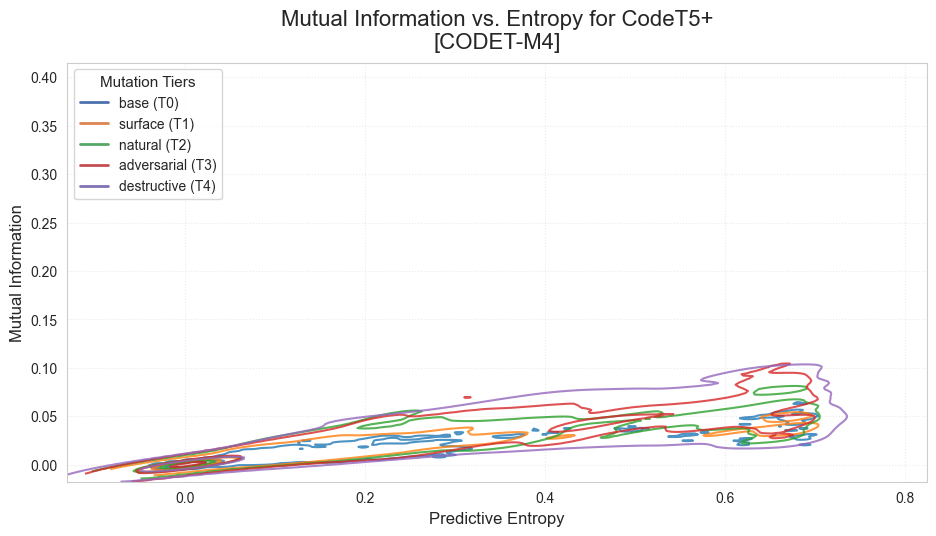

Saved: output\figures\codet_m4_mi_entropy_kde_deepseek.pdf


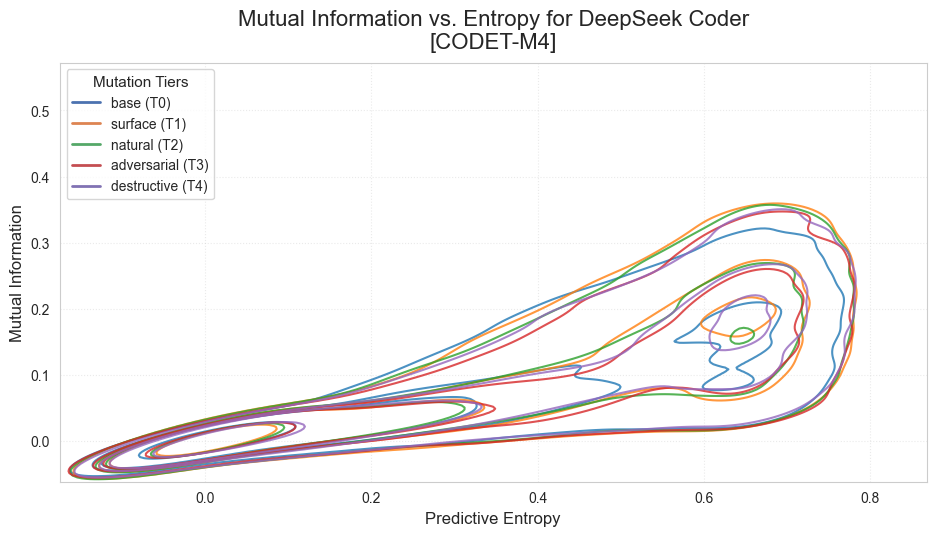

In [9]:
def plot_model_mi_entropy_kde(df_source, models=ALL_MODELS, tiers=TIER_ORDER):
    df_clean = df_source.copy()

    df_clean = df_clean[df_clean["true_label"] != "true_label"]
    df_clean["entropy"] = pd.to_numeric(df_clean["entropy"], errors="coerce")
    df_clean["mutual_info"] = pd.to_numeric(df_clean["mutual_info"], errors="coerce")
    
    df_clean = df_clean.dropna(subset=["entropy", "mutual_info", "tier", "model_name"])

    for model in models:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.grid(True, linestyle=":", alpha=0.4)
        
        df_model = df_clean[df_clean["model_name"] == model]
        
        if df_model.empty:
            ax.set_title(f"No data for model: {model}")
            continue

        sns.kdeplot(
            data=df_model,
            x="entropy",
            y="mutual_info",
            hue="tier",
            hue_order=tiers,
            ax=ax,
            fill=False,
            levels=5,
            linewidths=1.5,
            alpha=0.8,
            warn_singular=False
        )

        ds_title = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        ax.set_title(f"Mutual Information vs. Entropy for {MODEL_LABELS[model]}\n{ds_title}", fontsize=16, pad=10)
        ax.set_xlabel("Predictive Entropy", fontsize=12)
        ax.set_ylabel("Mutual Information", fontsize=12)

        handles = [
            Line2D([0], [0], color=sns.color_palette("deep", len(tiers))[i], lw=2)
            for i, t in enumerate(tiers)
        ]
        labels = [TIER_LABELS[t] for t in tiers]

        ax.legend(
            handles,
            labels,
            title="Mutation Tiers",
            frameon=True,
            fontsize=10,
            title_fontsize=11,
            loc="upper left",
        )

        save_figure(fig, f"{DATASET_NAME}_mi_entropy_kde_{model}")

        plt.tight_layout(pad=3.0)
        
        plt.show()

plot_model_mi_entropy_kde(df_raw)


## Ablation Study


##### Helpers

In [10]:
ABLATION_FILE_PREFIX = "tier_1_no_"


def format_tier_label(tier_name):
    return tier_name.replace(ABLATION_FILE_PREFIX, "T1 - no ").replace("_", " ")


def build_ablation_summary(base_dir=Path("data/fine_tune/models")):
    raw_abl_frames = []

    for csv_path in sorted(base_dir.rglob("tier_*_ablation_metrics_*.csv")):
        ablation_df = pd.read_csv(csv_path)
        ablation_df = ablation_df[ablation_df["true_label"] != "true_label"]

        raw_abl_frames.append(ablation_df)

    if not raw_abl_frames:
        return pd.DataFrame(), pd.DataFrame()

    df_raw_abl = pd.concat(raw_abl_frames, ignore_index=True)
    abl_tiers = df_raw_abl["tier"].unique()

    df_clean_abl = build_metrics_summary(df_raw_abl, tiers=abl_tiers)

    return df_clean_abl, abl_tiers


##### Generate Bar Plot

Saved: output\figures\codet_m4_ablation_accuracy_tier_1.pdf


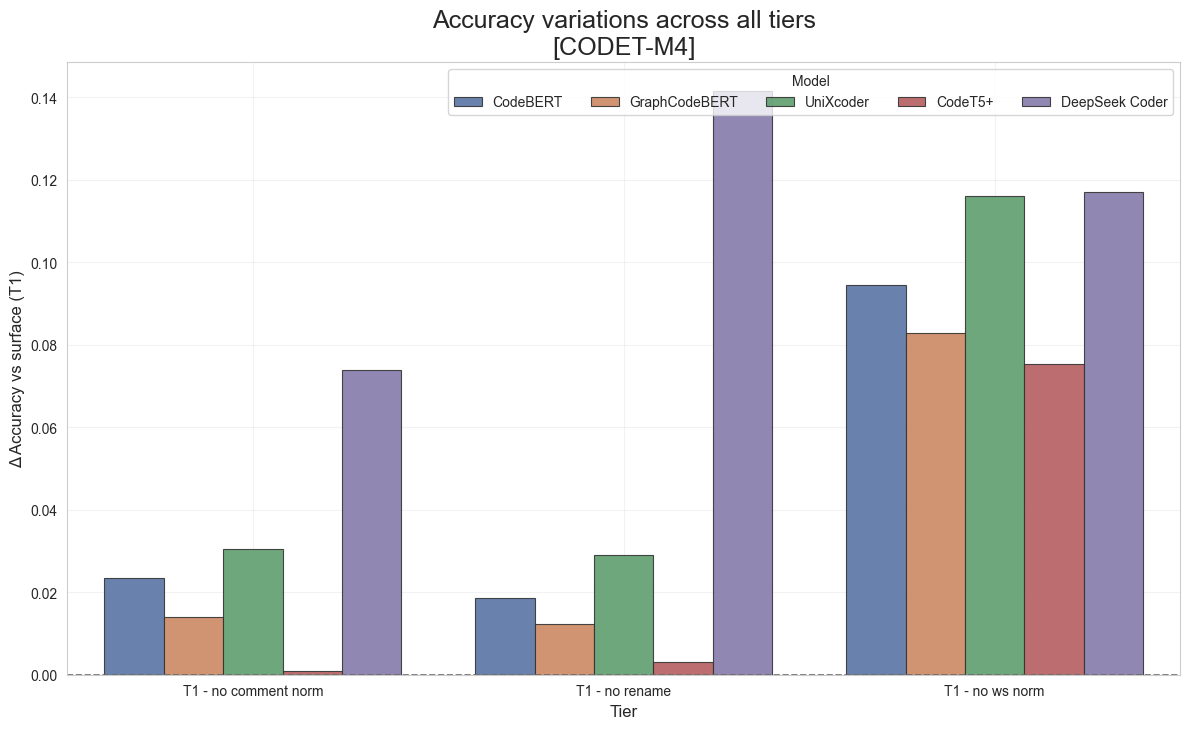

Saved: output\figures\codet_m4_ablation_macro_f1_tier_1.pdf


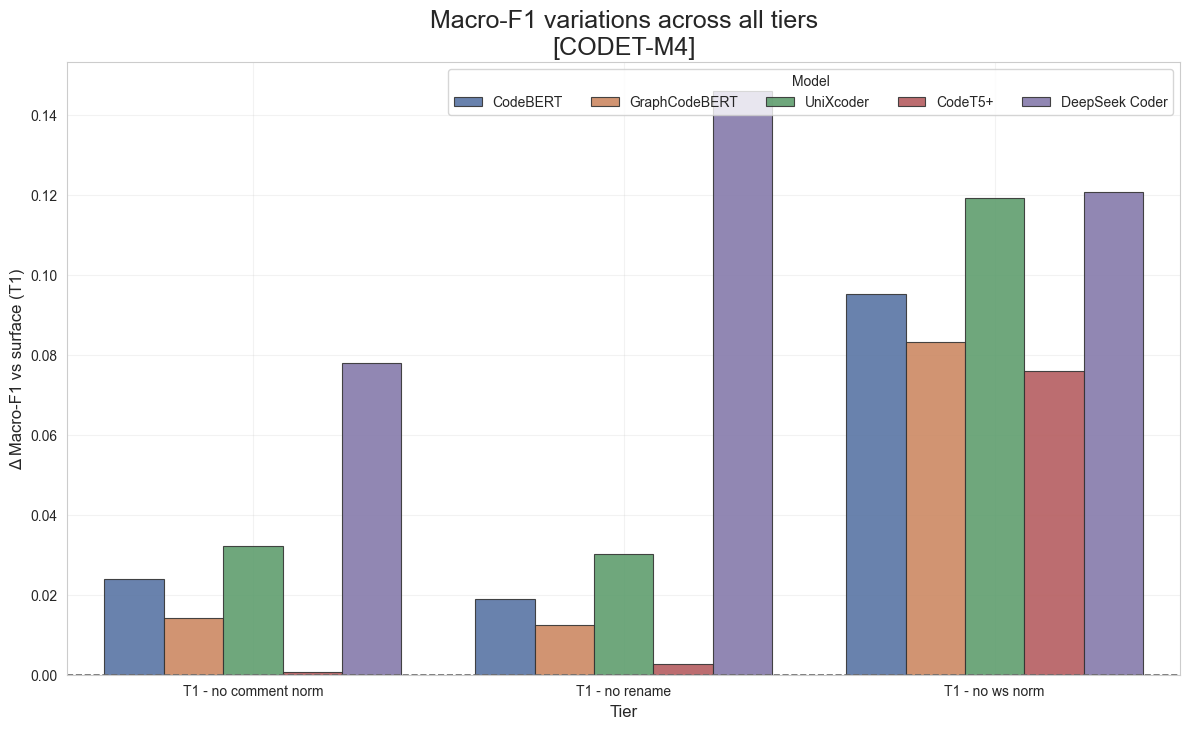

In [11]:
def plot_ablation_barplot(summary_df, tiers, baseline, models=ALL_MODELS, metrics=["accuracy", "macro_f1"]):
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(12, 7.4))
        x = np.arange(len(tiers))

        plot_data = []
        for model in models:
            model_df: DataFrame = summary_df[summary_df["model_name"] == model]
            model_df = model_df.groupby("tier").mean(numeric_only=True).reindex(tiers)
            delta_col = f"{metric}_delta" if f"{metric}_delta" in model_df.columns else metric

            for tier in tiers:
                val = model_df.loc[tier, delta_col]
                plot_data.append(
                    {
                        "tier": tier,
                        "model_pretty": MODEL_LABELS[model],
                        "delta": val if pd.notna(val) else 0.0,
                    }
                )

        plot_df = pd.DataFrame(plot_data)
        hue_order = [MODEL_LABELS[m] for m in models]
        palette = {MODEL_LABELS[m]: MODEL_COLORS.get(m, "#333333") for m in models}

        sns.barplot(
            data=plot_df,
            x="tier",
            y="delta",
            hue="model_pretty",
            hue_order=hue_order,
            order=tiers,
            palette=palette,
            ax=ax,
            edgecolor="#333333",
            linewidth=0.8,
            alpha=0.9,
        )

        ax.axhline(0.0, color="#666666", linestyle="--", linewidth=1.2)
        ds_name = f"[{DATASET_NAME.upper().replace('_', '-')}]"
        ax.set_title(
            f"{METRIC_LABELS[metric]} variations across all tiers\n{ds_name}",
            fontsize=18,
            fontweight="medium",
        )
        ax.set_xlabel("Tier", fontsize=12)
        ax.set_ylabel(f"{METRIC_DELTA_LABELS[metric]} vs {TIER_LABELS[baseline]}", fontsize=12)

        ax.set_xticks(x)
        ax.set_xticklabels([format_tier_label(t) for t in tiers])
        ax.grid(alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles,
                labels,
                title="Model",
                ncol=min(len(labels), 5),
                frameon=True,
                fontsize=10,
            )

        fig.tight_layout()
        tier_name = "_".join(tiers[0].split("_")[:2])

        save_figure(fig, f"{DATASET_NAME}_ablation_{metric}_{tier_name}")
        plt.show()


baseline = "tier_1"

ablation_summary_df, abl_tiers = build_ablation_summary()
raw_summary_df = build_metrics_summary(df_raw, tiers=np.array([baseline]))
combined_df = pd.concat([raw_summary_df, ablation_summary_df], ignore_index=True)
delta_summary_df = build_delta_summary(combined_df, baseline)

plot_ablation_barplot(delta_summary_df, abl_tiers, baseline)
